## Binning and Binarization | Discretization | Quantile Binning | KMeans Binning

### Binning (Discretization)

Binning is a technique in which continuous numerical data is converted into groups (bins or intervals).

👉 Example:

Age: 0–10, 11–20, 21–30
Salary: Low, Medium, High

✔ Used for:

Reducing noise in data
Making data simpler
Helping models handle continuous values better

In [1]:
import pandas as pd
import numpy as np

In [2]:
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score

from sklearn.model_selection import cross_val_score


from sklearn.preprocessing import KBinsDiscretizer
from sklearn.compose import ColumnTransformer


In [3]:
df = pd.read_csv('titanic_train.csv', usecols =['Age','Fare','Survived'])

In [4]:
df.dropna(inplace=True)

In [5]:
df.shape

(714, 3)

In [6]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [7]:
X = df.iloc[:,1:]
y = df.iloc[:,0]

In [8]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state = 42)

In [9]:
X_train.head(2)

,Age,Fare
328,31.0,20.5250
73,26.0,14.4542


In [15]:
clf = DecisionTreeClassifier()

In [18]:
clf.fit(X_train,y_train)
y_pred = clf.predict(X_test)

In [19]:
accuracy_score(y_test,y_pred)

0.6363636363636364

In [20]:
np.mean(cross_val_score(DecisionTreeClassifier(),X,y,cv=10,scoring='accuracy'))

np.float64(0.6317292644757433)

In [23]:
kbin_age = KBinsDiscretizer(n_bins=10,encode='ordinal',strategy='quantile')
kbin_fare = KBinsDiscretizer(n_bins=10,encode='ordinal',strategy='quantile')

In [25]:
trf = ColumnTransformer([
    ('first',kbin_age,[0]),
    ('second',kbin_fare,[1])
])

In [47]:
X_train_trf = trf.fit_transform(X_train)
X_test_trf = trf.transform(X_test)

c:\Users\udaya\anaconda3\Lib\site-packages\sklearn\preprocessing\_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
c:\Users\udaya\anaconda3\Lib\site-packages\sklearn\preprocessing\_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(


In [48]:
trf.named_transformers_['second'].bin_edges_

array([array([  0.    ,   7.75  ,   7.8958,   9.225 ,  13.    ,  15.75  ,
               26.    ,  29.125 ,  51.4792,  82.1708, 512.3292])         ],
      dtype=object)

In [49]:
trf.named_transformers_['first'].bin_edges_

array([array([ 0.42, 14.  , 19.  , 22.  , 25.  , 28.5 , 32.  , 36.  , 42.  ,
              50.  , 80.  ])                                                ],
      dtype=object)

In [50]:
output = pd.DataFrame({
    'age':X_train['Age'],
    'age_trf':X_train_trf[:,0],
    'fare':X_train['Fare'],
    'fare_trf':X_train_trf[:,1]
})

In [51]:
output['age_labels'] = pd.cut(x=X_train['Age'],
bins = trf.named_transformers_['first'].bin_edges_[0].tolist())

output['fare_labels'] = pd.cut(x=X_train['Fare'],
bins=trf.named_transformers_['second'].bin_edges_[0].tolist())

In [52]:
output.sample(5)

,age,age_trf,fare,fare_trf,age_labels,fare_labels
387,36.0,7.0,13.0000,4.0,"(32.0, 36.0]","(9.225, 13.0]"
649,23.0,3.0,7.5500,0.0,"(22.0, 25.0]","(0.0, 7.75]"
729,25.0,4.0,7.9250,2.0,"(22.0, 25.0]","(7.896, 9.225]"
390,36.0,7.0,120.0000,9.0,"(32.0, 36.0]","(82.171, 512.329]"
686,14.0,1.0,39.6875,7.0,"(0.42, 14.0]","(29.125, 51.479]"


In [53]:
clf = DecisionTreeClassifier()
clf.fit(X_train_trf,y_train)
y_pred2 = clf.predict(X_test_trf)

In [54]:
accuracy_score(y_test,y_pred2)

0.6223776223776224

In [55]:
def discretize(bins, strategy):

    kbin_age = KBinsDiscretizer(
        n_bins=bins,
        encode='ordinal',
        strategy=strategy
    )

    kbin_fare = KBinsDiscretizer(
        n_bins=bins,
        encode='ordinal',
        strategy=strategy
    )

    trf = ColumnTransformer([
        ('first', kbin_age, [0]),
        ('second', kbin_fare, [1])
    ])

    X_trf = trf.fit_transform(X)

    print(
        np.mean(
            cross_val_score(
                DecisionTreeClassifier(),
                X,
                y,
                cv=10,
                scoring='accuracy'
            )
        )
    )

    plt.figure(figsize=(14, 4))

    plt.subplot(121)
    plt.hist(X['Age'])
    plt.title("Before")

    plt.subplot(122)
    plt.hist(X_trf[:, 0], color='red')
    plt.title("After")

    plt.show()

0.6274843505477308


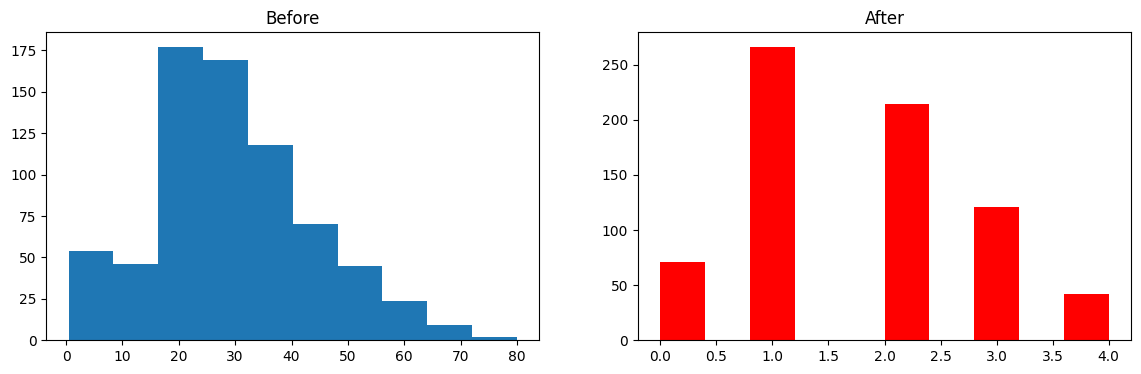

In [58]:
discretize(5,'kmeans')